In [199]:
import geopandas as gpd
import pandas as pd
import gpxpy
import glob
import gpxpy.gpx
from shapely.geometry import LineString
import matplotlib.pyplot as plt
from shapely.geometry import Point
import contextily as ctx
import matplotlib.animation as animation
import numpy as np
from utils import *
import osmnx as ox
    

In [2]:
G = ox.graph.graph_from_place("Barcelone, Spain", network_type="drive")

In [9]:
Gracia = ox.graph.graph_from_place("Gracia, Barcelone, Spain", network_type="drive")

In [16]:
Guinardo = ox.graph.graph_from_place("Baix-Guinardo, Barcelone, Spain", network_type="drive")

In [43]:
%matplotlib widget

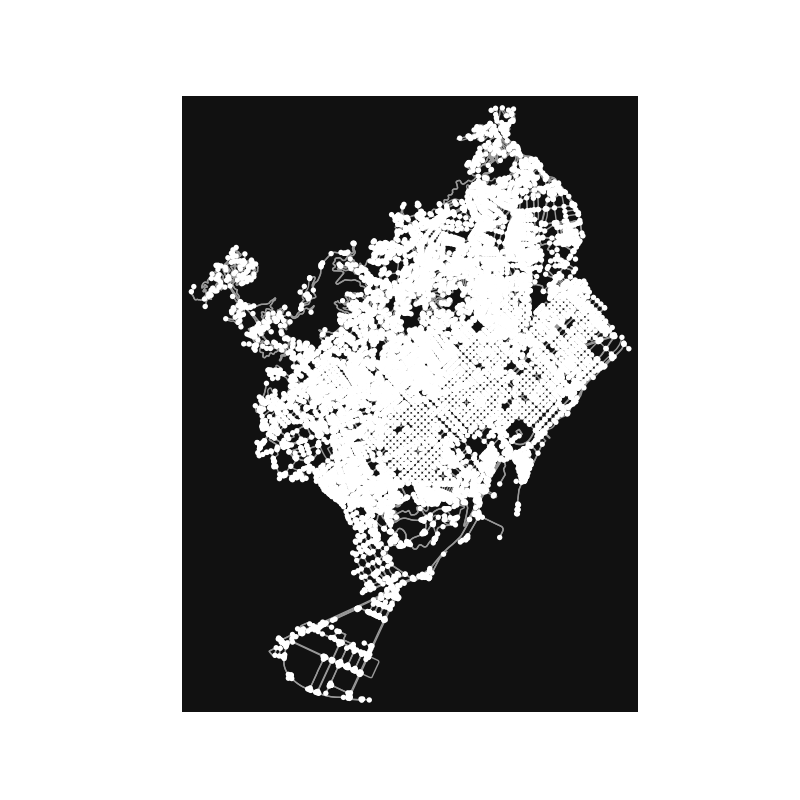

In [44]:
fig, ax = ox.plot.plot_graph(G)

In [163]:
%matplotlib inline

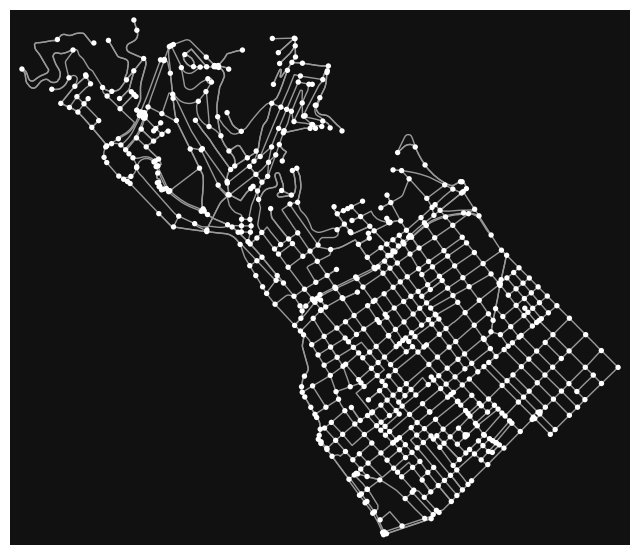

In [156]:
fig, ax = ox.plot.plot_graph(Gracia)

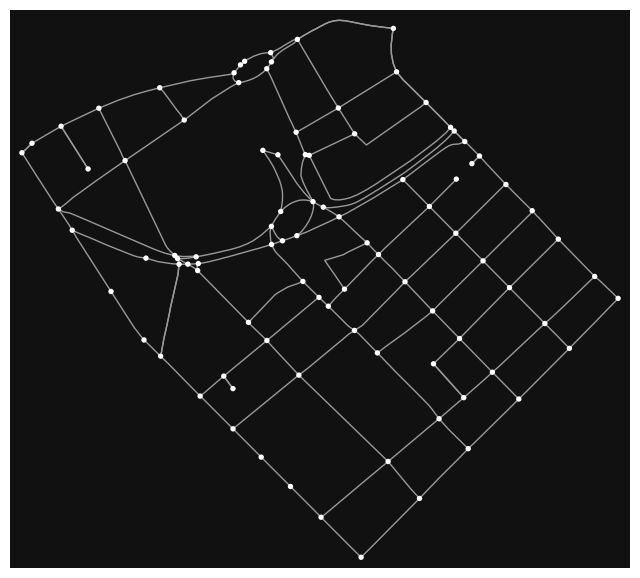

In [17]:
fig, ax = ox.plot.plot_graph(Guinardo)

In [18]:
G_proj = ox.projection.project_graph(G)
nodes_proj = ox.convert.graph_to_gdfs(G_proj, edges=False)
graph_area_m = nodes_proj.union_all().convex_hull.area
graph_area_m = nodes_proj.union_all().convex_hull.area
Gracia_proj = ox.projection.project_graph(Gracia)
nodes_gracia_proj = ox.convert.graph_to_gdfs(Gracia_proj, edges=False)
graph_gracia_area_m = nodes_gracia_proj.union_all().convex_hull.area
graph_gracia_area_m = nodes_gracia_proj.union_all().convex_hull.area

In [195]:
stats = ox.stats.basic_stats(G_proj, area=graph_area_m, clean_int_tol=15)
stats

{'n': 8896,
 'm': 16493,
 'k_avg': 3.7079586330935252,
 'edge_length_total': 1671639.3737025561,
 'edge_length_avg': 101.35447606272699,
 'streets_per_node_avg': 3.1551258992805757,
 'streets_per_node_counts': {0: 0,
  1: 644,
  2: 150,
  3: 5393,
  4: 2614,
  5: 81,
  6: 14},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.07239208633093525,
  2: 0.016861510791366906,
  3: 0.6062275179856115,
  4: 0.29383992805755393,
  5: 0.00910521582733813,
  6: 0.0015737410071942446},
 'intersection_count': 8252,
 'street_length_total': 1387740.5754353616,
 'street_segment_count': 13956,
 'street_length_avg': 99.43684260786483,
 'circuity_avg': 1.049535587137089,
 'self_loop_proportion': 0.0009314989968472342,
 'clean_intersection_count': 5853,
 'node_density_km': 75.4076603013751,
 'intersection_density_km': 69.94874244682411,
 'edge_density_km': 14169.78575073806,
 'street_density_km': 11763.29472783999,
 'clean_intersection_density_km': 49.61342578056974}

In [158]:
total_street_length = stats["edge_length_total"]/1000.
total_street_length


1671.6393737025562

In [20]:
stats_gracia = ox.stats.basic_stats(Gracia_proj, area=graph_gracia_area_m, clean_int_tol=15)
total_street_length_gracia = stats_gracia["edge_length_total"]/1000.
total_street_length_gracia
stats_gracia

{'n': 745,
 'm': 1324,
 'k_avg': 3.5543624161073826,
 'edge_length_total': 110567.0538273144,
 'edge_length_avg': 83.50985938618913,
 'streets_per_node_avg': 3.1369127516778526,
 'streets_per_node_counts': {0: 0, 1: 64, 2: 12, 3: 434, 4: 229, 5: 5, 6: 1},
 'streets_per_node_proportions': {0: 0.0,
  1: 0.08590604026845637,
  2: 0.016107382550335572,
  3: 0.5825503355704698,
  4: 0.3073825503355705,
  5: 0.006711409395973154,
  6: 0.0013422818791946308},
 'intersection_count': 681,
 'street_length_total': 91911.29299080143,
 'street_segment_count': 1123,
 'street_length_avg': 81.84442830881694,
 'circuity_avg': 1.03720567660894,
 'self_loop_proportion': 0.0,
 'clean_intersection_count': 529,
 'node_density_km': 6.3150524870193845,
 'intersection_density_km': 5.772551333772082,
 'edge_density_km': 937.2305345699168,
 'street_density_km': 779.0934756868832,
 'clean_intersection_density_km': 4.484111094809737}

In [159]:
node_id = list(G.nodes)[0]
G.nodes[node_id]

{'y': 41.3700925, 'x': 2.187743, 'street_count': 3}

In [45]:
nth_edge = 5
print("Attributes for the first",nth_edge,"edges")
for i, (u, v, k, data) in enumerate(G.edges(keys=True, data=True)):
    print(f"Edge ({u}, {v}, {k}):")
    print(data["name"])
    for key, value in data.items():
        print(f"  - {key}: {value}")
    
    if i >= nth_edge:
        break

Attributes for the first 5 edges
Edge (21638845, 885308258, 0):
Passeig de Joan de Borbó
  - osmid: 554707785
  - highway: residential
  - lanes: 2
  - maxspeed: 30
  - name: Passeig de Joan de Borbó
  - oneway: True
  - reversed: False
  - length: 28.33475962697731
Edge (21638845, 13175411896, 0):
Passeig de Joan de Borbó
  - osmid: [1433594636, 4079500, 543357596, 902517725, 423227070]
  - highway: residential
  - lanes: ['4', '3']
  - maxspeed: 30
  - name: Passeig de Joan de Borbó
  - oneway: False
  - reversed: True
  - length: 616.4811590433035
  - geometry: LINESTRING (2.187743 41.3700925, 2.1876862 41.3701691, 2.187646 41.3702497, 2.1876269 41.3702846, 2.1875931 41.3703647, 2.1876124 41.3705394, 2.1876143 41.3705512, 2.187617 41.3705677, 2.1876623 41.3708496, 2.1876664 41.3708748, 2.1877927 41.3716585, 2.1877969 41.3716845, 2.1879173 41.3724315, 2.1879222 41.3724622, 2.1879268 41.372491, 2.1879373 41.3725507, 2.1879812 41.3728904, 2.1880545 41.3733609, 2.1880724 41.3734818, 2.1

In [46]:
edge_number = 6
nth_edge = None
edge_iterator = iter(G.edges(keys=True))

for _ in range(edge_number + 1):
        nth_edge = next(edge_iterator)
    
print("edge ", edge_number,nth_edge)


edge  6 (21638868, 30343649, 0)


In [47]:
coords_casa = [41.400971,2.160001] #from gmaps
coords_casa_hub = [41.4152636,2.1648925]

In [48]:
#test if lat,lon falls back on right street name
# 
u, v, k = ox.nearest_edges(
    G, 
    X=coords_casa[1], 
    Y=coords_casa[0]
)
print(u,v,k)
edge_attributes = G.get_edge_data(u, v, k)
edge_attributes.get('name')

30254379 30333334 0


'Carrer de la Fraternitat'

In [49]:
u, v, k = ox.nearest_edges(
    G, 
    X=coords_casa_hub[1], 
    Y=coords_casa_hub[0]
)
print(u,v,k)
edge_attributes = G.get_edge_data(u, v, k)
edge_attributes.get('name')

849592994 30688839 0


'Carrer de Polònia'

In [172]:
def get_edge_from_coords(coords):
    u, v, k = ox.nearest_edges(
    G, 
    X=coords[1], 
    Y=coords[0]
    )
    #print(u,v,k)
    edge_attributes = G.get_edge_data(u, v, k)
    if type(edge_attributes.get('name')) == str:  
        street_name = edge_attributes.get('name') #usually a string
    else:
        try:
            street_name = edge_attributes.get('name')[0] #edge with coords (41.4049091 2.1738864), (41.4052928 2.1755545) has Provenca and Marina
        except:
            street_name = "Unkwown" # edge from point 867 or 868 from PA has no street name
    #print(type(street_name),street_name)

    return((u,v,k),street_name)
    

In [173]:
edge_casa , street_name_casa = get_edge_from_coords(coords_casa)
edge_hub ,street_name_hub = get_edge_from_coords(coords_casa_hub)
problematic_edge = [30555974, 1396408887, 0]
problematic_edge_attributes=G.get_edge_data(30555974, 1396408887, 0)
print(G.nodes[1396408887]['y'],G.nodes[1396408887]['x'])
print(G.nodes[30555974]['y'],G.nodes[30555974]['x'])
problematic_edge_attributes.get('name')


41.4049091 2.1738864
41.4052928 2.1755545


['Carrer de la Marina', 'Carrer de Provença']

In [174]:
nodes_gdf, edges_gdf = ox.convert.graph_to_gdfs(G, nodes=True, edges=True, node_geometry=True, fill_edge_geometry=True)
print("node0:",nodes_gdf.iloc[0])
print("edge0:",edges_gdf.iloc[0])

node0: y                                 41.370092
x                                  2.187743
street_count                              3
ref                                     NaN
highway                                 NaN
junction                                NaN
railway                                 NaN
geometry        POINT (2.187743 41.3700925)
Name: 21638845, dtype: object
edge0: osmid                                                554707785
highway                                            residential
lanes                                                        2
maxspeed                                                    30
name                                  Passeig de Joan de Borbó
oneway                                                    True
reversed                                                 False
length                                                28.33476
geometry     LINESTRING (2.187743 41.3700925, 2.1877072 41....
access                               

In [178]:
def get_coords_gpx(user,n_segments=None):
    file = glob.glob(f'segments/{user}/*.gpx')[0] 
    gpx_file = open(file, 'r') 
    gpx = gpxpy.parse(gpx_file) 
    coords_gpx = []
    for track in gpx.tracks:
        for s, segment in enumerate(gpx.tracks[0].segments):
            if (user == 'hubert') & (s in [1, 6]):
                continue
            if n_segments and s >= n_segments:
                return coords_gpx
            for points in segment.points:
                coords_gpx.append((points.latitude,points.longitude))
    return coords_gpx
coords_gpx_pa = get_coords_gpx("pa")
len(coords_gpx_pa)


5022

In [179]:
#list_edges = [edge_casa,edge_hub]
list_edges = []
i=0
for lat, lon in coords_gpx_pa:
  #  if i < 100:
        print(i,"/",len(coords_gpx_pa))
        edge_and_name = get_edge_from_coords((lat,lon))
        #print("edge_and_name",edge_and_name)
        if edge_and_name not in list_edges:
            list_edges.append(edge_and_name)
       # list_edges[i]
        #if in new edge, add to the list of edges 
        #else:
        #    print("repeated")
        #shows the number of points per edges
        i=i+1
  #  else:
  #      break
list_edges

0 / 5022
1 / 5022
2 / 5022
3 / 5022
4 / 5022
5 / 5022
6 / 5022
7 / 5022
8 / 5022
9 / 5022
10 / 5022
11 / 5022
12 / 5022
13 / 5022
14 / 5022
15 / 5022
16 / 5022
17 / 5022
18 / 5022
19 / 5022
20 / 5022
21 / 5022
22 / 5022
23 / 5022
24 / 5022
25 / 5022
26 / 5022
27 / 5022
28 / 5022
29 / 5022
30 / 5022
31 / 5022
32 / 5022
33 / 5022
34 / 5022
35 / 5022
36 / 5022
37 / 5022
38 / 5022
39 / 5022
40 / 5022
41 / 5022
42 / 5022
43 / 5022
44 / 5022
45 / 5022
46 / 5022
47 / 5022
48 / 5022
49 / 5022
50 / 5022
51 / 5022
52 / 5022
53 / 5022
54 / 5022
55 / 5022
56 / 5022
57 / 5022
58 / 5022
59 / 5022
60 / 5022
61 / 5022
62 / 5022
63 / 5022
64 / 5022
65 / 5022
66 / 5022
67 / 5022
68 / 5022
69 / 5022
70 / 5022
71 / 5022
72 / 5022
73 / 5022
74 / 5022
75 / 5022
76 / 5022
77 / 5022
78 / 5022
79 / 5022
80 / 5022
81 / 5022
82 / 5022
83 / 5022
84 / 5022
85 / 5022
86 / 5022
87 / 5022
88 / 5022
89 / 5022
90 / 5022
91 / 5022
92 / 5022
93 / 5022
94 / 5022
95 / 5022
96 / 5022
97 / 5022
98 / 5022
99 / 5022
100 / 5022

[((126797329, 126803368, 0), 'Carrer de Provença'),
 ((30243117, 126797329, 0), 'Carrer de Provença'),
 ((30243160, 30243117, 0), 'Carrer de Provença'),
 ((30254194, 30243160, 0), 'Carrer de Provença'),
 ((30254194, 30253568, 0), 'Carrer de Sicília'),
 ((30555972, 30254194, 0), 'Carrer de Provença'),
 ((1396408886, 30555972, 0), 'Carrer de Sardenya'),
 ((30555972, 30242962, 0), 'Carrer de Sardenya'),
 ((1396408887, 1396408886, 0), 'passatge de Francesca Simon'),
 ((30555974, 1396408887, 0), 'Carrer de la Marina'),
 ((667410900, 30555974, 0), 'Carrer de Lepant'),
 ((30254056, 30555974, 0), 'Carrer de Provença'),
 ((30254056, 1845692293, 0), 'Carrer de Padilla'),
 ((30555975, 30254056, 0), 'Carrer de Provença'),
 ((30253572, 30555975, 0), 'Carrer de los Castillejos'),
 ((30555975, 30254029, 0), 'Carrer de los Castillejos'),
 ((30243394, 30254029, 0), 'Carrer de Mallorca'),
 ((30254029, 30243334, 0), 'Carrer de los Castillejos'),
 ((30243334, 30555687, 0), 'Carrer de València'),
 ((305556

In [180]:

highlighted_edges_set = {
    data[0] 
    for data in list_edges
}



edge_colors = []
for u, v, k in G.edges(keys=True):
    # The edge identifier is the tuple (u, v, k)
    edge_id = (u, v, k)
    
    if edge_id in highlighted_edges_set:
        # Assign red if the edge is in your list
        edge_colors.append("r")
     #   print("highligh",edge_id)
    else:
        # Assign black if the edge is NOT in your list
        edge_colors.append("k")
      #  print("normal",edge_id)

In [169]:
#type(list_edges)
#n=len(list_edges)
#list_edges[:][0]
#edge_colors

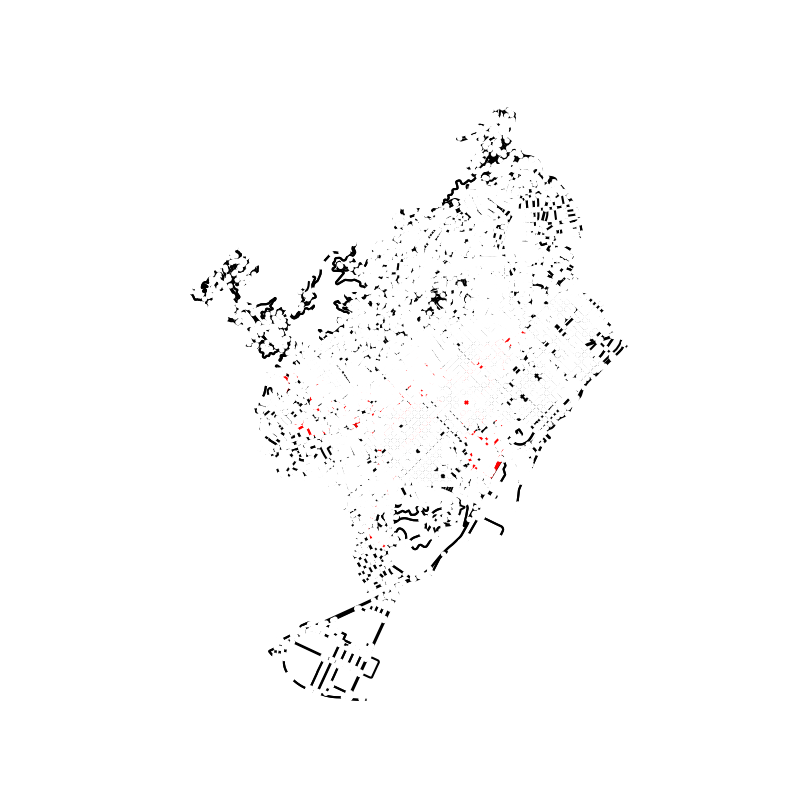

In [183]:
fig, ax = ox.plot.plot_graph(
    G,
    edge_color=edge_colors,
    edge_linewidth=1.5,
    show=False,
    close=False,
    bgcolor="w"
)

In [188]:
visited_street_names = [edge_data[1] for edge_data in list_edges]
len(set(visited_street_names))

369

In [181]:
%matplotlib widget

In [167]:
%matplotlib inline

In [191]:
def get_graph_street_names(graph):
    
    unique_street_names_from_G = set()

# Iterate over all edges in the graph, retrieving the attribute data for each edge
# We use keys=False because the u, v, k are not strictly needed for this task,
# only the data dictionary is.
    for _, _, data in graph.edges(data=True):
    # The street name is stored under the key 'name'
        name_entry = data.get('name')
    
    # Check if the 'name' attribute exists
        if name_entry is not None:
            
            if isinstance(name_entry, list):
                # If the value is a list (multiple names), add all individual names to the set
                for name in name_entry:
                    unique_street_names_from_G.add(name)
            elif isinstance(name_entry, str):
            # If the value is a single string, add it to the set
                unique_street_names_from_G.add(name_entry)

# The count of unique street names is the length of the final set
    count_unique_names_G = len(unique_street_names_from_G)
    print("Total number of streets",count_unique_names_G)
    return count_unique_names_G


In [207]:
get_graph_street_names(G)
get_graph_street_names(Gracia)
len(set(visited_street_names))/get_graph_street_names(G)*100


Total number of streets 2912
Total number of streets 318
Total number of streets 2912


12.671703296703296

In [209]:
street_percentage = len(set(visited_street_names))/get_graph_street_names(G)*100
df = pd.DataFrame({
    "number of mapped streets": [len(set(visited_street_names))],
    "total number of streets": [get_graph_street_names(G)],
    "percentage street": [street_percentage],
    "number of mapped segments ":[len(list_edges)],
    "total number of segments" : [stats["m"]], 
    "percentage segments": [len(list_edges)/stats["m"]*100],
    "mapped kms": ["-"],
    "total street length": [stats["edge_length_total"] /1000],
    "percentage km": ["-"]
})
df.style \
  .format(precision=3, thousands=".", decimal=",") \
  .format_index(str.upper, axis=1) \
  .relabel_index(["Barcelona"], axis=0)

Total number of streets 2912
Total number of streets 2912


,NUMBER OF MAPPED STREETS,TOTAL NUMBER OF STREETS,PERCENTAGE STREET,NUMBER OF MAPPED SEGMENTS,TOTAL NUMBER OF SEGMENTS,PERCENTAGE SEGMENTS,MAPPED KMS,TOTAL STREET LENGTH,PERCENTAGE KM
Barcelona,369,2.912,"12,672",1.247,16.493,"7,561",-,"1.671,639",-
